In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
customers = pd.read_csv('../data/customers.csv')
transactions = pd.read_csv('../data/transactions.csv')

print("Customers shape:", customers.shape)
print("Transactions shape:", transactions.shape)
print("\nCustomers columns:", customers.columns.tolist())
print("\nTransactions columns:", transactions.columns.tolist())

Customers shape: (10000, 11)
Transactions shape: (100000, 10)

Customers columns: ['customer_id', 'name', 'age', 'city', 'occupation', 'card_tier', 'credit_limit', 'credit_score', 'tenure_months', 'annual_fee', 'is_active']

Transactions columns: ['transaction_id', 'customer_id', 'transaction_date', 'category', 'channel', 'amount', 'interest_charged', 'city', 'card_tier', 'is_defaulted']


In [3]:
# Merge customers and transactions
df = transactions.merge(customers[['customer_id', 'name', 'occupation', 'age', 'credit_score', 'tenure_months']], 
                        on='customer_id', how='left')

# Convert date column
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['month'] = df['transaction_date'].dt.to_period('M')
df['month_name'] = df['transaction_date'].dt.strftime('%b %Y')

# Key metrics
print("=" * 40)
print("KEY BUSINESS METRICS")
print("=" * 40)
print(f"Total Transactions : {len(df):,}")
print(f"Total GMV          : ₹{df['amount'].sum():,.2f}")
print(f"Total Interest     : ₹{df['interest_charged'].sum():,.2f}")
print(f"Total Revenue      : ₹{(df['amount'].sum() + df['interest_charged'].sum()):,.2f}")
print(f"Avg Transaction    : ₹{df['amount'].mean():,.2f}")
print(f"Default Rate       : {df['is_defaulted'].mean()*100:.2f}%")
print("=" * 40)

KEY BUSINESS METRICS
Total Transactions : 100,000
Total GMV          : ₹697,407,151.10
Total Interest     : ₹7,358,535.65
Total Revenue      : ₹704,765,686.75
Avg Transaction    : ₹6,974.07
Default Rate       : 3.04%


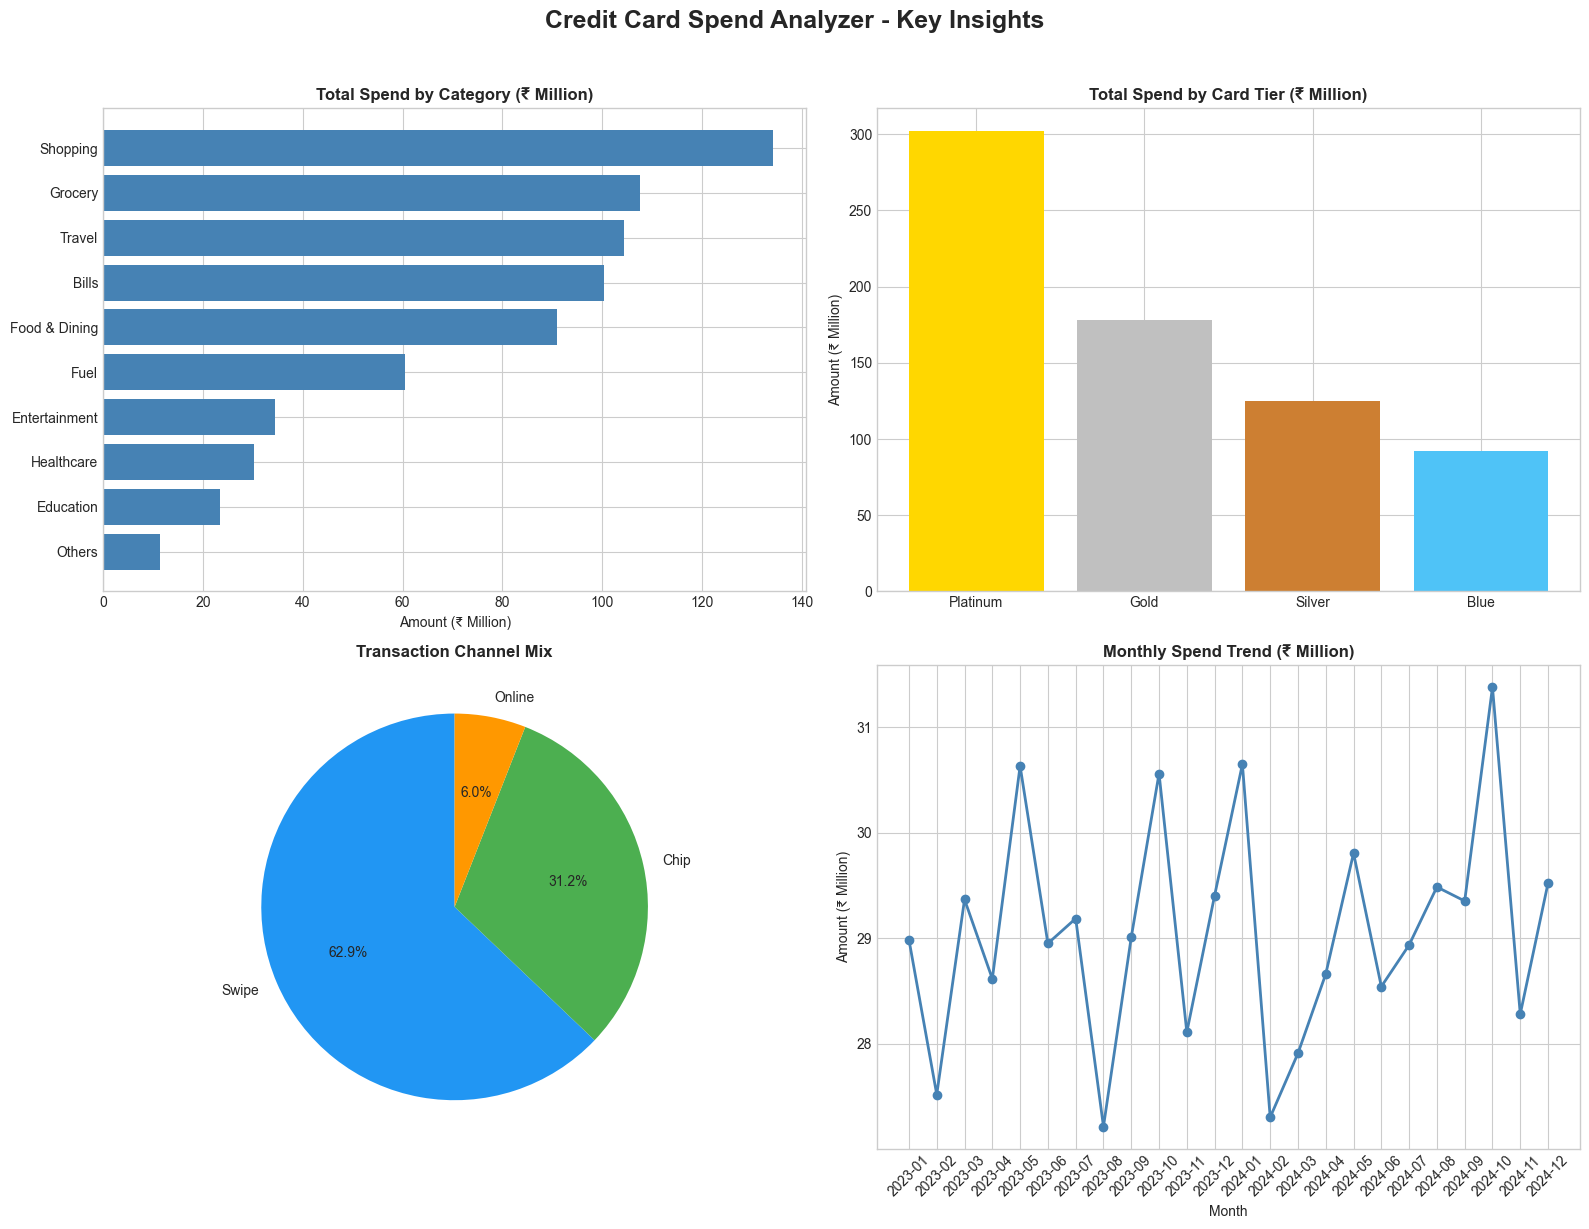

Chart saved!


In [4]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Credit Card Spend Analyzer - Key Insights', fontsize=18, fontweight='bold', y=1.02)

# Chart 1 - Spend by Category
cat_spend = df.groupby('category')['amount'].sum().sort_values(ascending=True)
axes[0,0].barh(cat_spend.index, cat_spend.values / 1e6, color='steelblue')
axes[0,0].set_title('Total Spend by Category (₹ Million)', fontweight='bold')
axes[0,0].set_xlabel('Amount (₹ Million)')

# Chart 2 - Revenue by Card Tier
tier_spend = df.groupby('card_tier')['amount'].sum().sort_values(ascending=False)
colors = ['gold', 'silver', '#CD7F32', '#4FC3F7']
axes[0,1].bar(tier_spend.index, tier_spend.values / 1e6, color=colors)
axes[0,1].set_title('Total Spend by Card Tier (₹ Million)', fontweight='bold')
axes[0,1].set_ylabel('Amount (₹ Million)')

# Chart 3 - Channel Mix
channel_counts = df['channel'].value_counts()
axes[1,0].pie(channel_counts.values, labels=channel_counts.index, 
              autopct='%1.1f%%', startangle=90,
              colors=['#2196F3', '#4CAF50', '#FF9800'])
axes[1,0].set_title('Transaction Channel Mix', fontweight='bold')

# Chart 4 - Monthly Spend Trend
monthly = df.groupby('month')['amount'].sum().reset_index()
monthly['month_str'] = monthly['month'].astype(str)
axes[1,1].plot(monthly['month_str'], monthly['amount'] / 1e6, 
               marker='o', color='steelblue', linewidth=2)
axes[1,1].set_title('Monthly Spend Trend (₹ Million)', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Amount (₹ Million)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../dashboard/chart1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

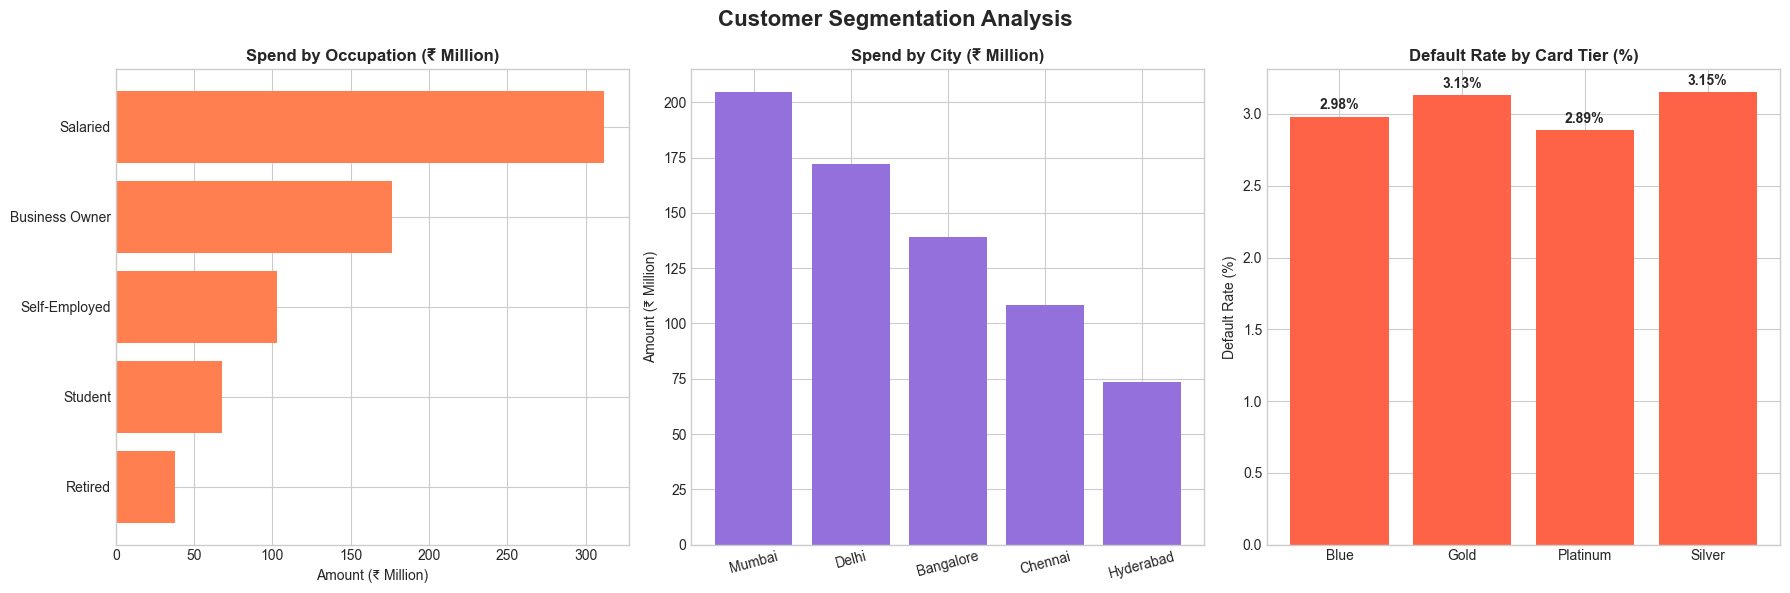

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Segmentation Analysis', fontsize=16, fontweight='bold')

# Chart 5 - Spend by Occupation
occ_spend = df.groupby('occupation')['amount'].sum().sort_values(ascending=True)
axes[0].barh(occ_spend.index, occ_spend.values / 1e6, color='coral')
axes[0].set_title('Spend by Occupation (₹ Million)', fontweight='bold')
axes[0].set_xlabel('Amount (₹ Million)')

# Chart 6 - City wise spend
city_spend = df.groupby('city')['amount'].sum().sort_values(ascending=False)
axes[1].bar(city_spend.index, city_spend.values / 1e6, color='mediumpurple')
axes[1].set_title('Spend by City (₹ Million)', fontweight='bold')
axes[1].set_ylabel('Amount (₹ Million)')
axes[1].tick_params(axis='x', rotation=15)

# Chart 7 - Default rate by tier
default_rate = df.groupby('card_tier')['is_defaulted'].mean() * 100
axes[2].bar(default_rate.index, default_rate.values, color='tomato')
axes[2].set_title('Default Rate by Card Tier (%)', fontweight='bold')
axes[2].set_ylabel('Default Rate (%)')
for i, v in enumerate(default_rate.values):
    axes[2].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/chart2_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

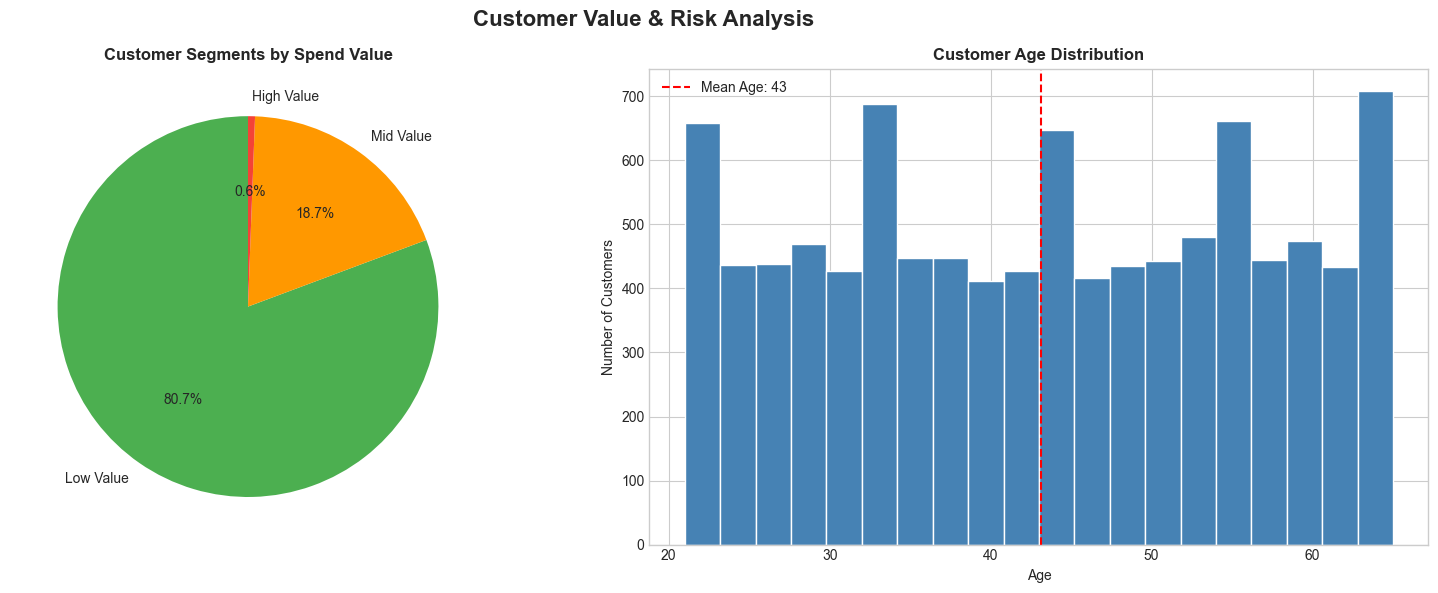

All charts saved! Check your dashboard folder.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Value & Risk Analysis', fontsize=16, fontweight='bold')

# Chart 8 - Customer segments by spend
customer_spend = df.groupby('customer_id')['amount'].sum().reset_index()
customer_spend['segment'] = pd.cut(customer_spend['amount'], 
                                    bins=[0, 100000, 500000, float('inf')],
                                    labels=['Low Value', 'Mid Value', 'High Value'])
segment_counts = customer_spend['segment'].value_counts()
colors = ['#4CAF50', '#FF9800', '#F44336']
axes[0].pie(segment_counts.values, labels=segment_counts.index,
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Customer Segments by Spend Value', fontweight='bold')

# Chart 9 - Age distribution of customers
axes[1].hist(customers['age'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Customer Age Distribution', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Customers')
axes[1].axvline(customers['age'].mean(), color='red', linestyle='--', 
                label=f'Mean Age: {customers["age"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../dashboard/chart3_customer_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("All charts saved! Check your dashboard folder.")